<a href="https://colab.research.google.com/github/NidhiDekate/car-price-multimodal-dl/blob/main/04_ML_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

base = '/content/drive/MyDrive/CarPricePrediction/'

# load preprocessed data
X_train = np.load(base + 'data/tabular/X_train.npy')
X_val   = np.load(base + 'data/tabular/X_val.npy')
X_test  = np.load(base + 'data/tabular/X_test.npy')

y_train = np.load(base + 'data/tabular/y_train.npy')
y_val   = np.load(base + 'data/tabular/y_val.npy')
y_test  = np.load(base + 'data/tabular/y_test.npy')

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)

Mounted at /content/drive
X_train: (28321, 12)
X_val: (6050, 12)
X_test: (6066, 12)
y_train: (28321,)


In [2]:
# evaluation helper
def evaluate(model_name, y_true, y_pred):
    # predictions are in log scale - convert back to dollars
    y_true_dollars = np.expm1(y_true)
    y_pred_dollars = np.expm1(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars))
    r2   = r2_score(y_true_dollars, y_pred_dollars)

    print(f"{model_name}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R2:   {r2:.4f}")
    return rmse, r2

In [3]:
from sklearn.linear_model import Ridge

# baseline
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

val_preds = ridge.predict(X_val)
baseline_rmse, baseline_r2 = evaluate("Ridge Regression (baseline)", y_val, val_preds)

Ridge Regression (baseline)
  RMSE: $6,731
  R2:   0.3529


In [4]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

val_preds = lgb_model.predict(X_val)
lgb_rmse, lgb_r2 = evaluate("LightGBM", y_val, val_preds)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.0319345
[200]	valid_0's l2: 0.0229894
[300]	valid_0's l2: 0.0205393
[400]	valid_0's l2: 0.0195254
[500]	valid_0's l2: 0.0189433
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 0.0189433
LightGBM
  RMSE: $2,168
  R2:   0.9329


In [6]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 28.2 MB/s eta 0:00:00


In [7]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=100
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

val_preds = cat_model.predict(X_val)
cat_rmse, cat_r2 = evaluate("CatBoost", y_val, val_preds)

0:	learn: 0.5579783	test: 0.5614502	best: 0.5614502 (0)	total: 48.8ms	remaining: 24.3s
100:	learn: 0.2395704	test: 0.2429790	best: 0.2429790 (100)	total: 267ms	remaining: 1.05s
200:	learn: 0.1965308	test: 0.2001483	best: 0.2001483 (200)	total: 475ms	remaining: 707ms
300:	learn: 0.1710671	test: 0.1759069	best: 0.1759069 (300)	total: 686ms	remaining: 454ms
400:	learn: 0.1554342	test: 0.1612077	best: 0.1612077 (400)	total: 900ms	remaining: 222ms
499:	learn: 0.1470277	test: 0.1536596	best: 0.1536596 (499)	total: 1.11s	remaining: 0us

bestTest = 0.1536595639
bestIteration = 499

CatBoost
  RMSE: $2,499
  R2:   0.9108


In [8]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_preds = xgb_model.predict(X_val)
xgb_rmse, xgb_r2 = evaluate("XGBoost", y_val, val_preds)

[0]	validation_0-rmse:0.55878
[100]	validation_0-rmse:0.18535
[200]	validation_0-rmse:0.15388
[300]	validation_0-rmse:0.14234
[400]	validation_0-rmse:0.13740
[499]	validation_0-rmse:0.13469
XGBoost
  RMSE: $1,872
  R2:   0.9500


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict

# get out-of-fold predictions from each model for stacking
print("getting oof predictions for stacking...")

lgb_oof = cross_val_predict(
    lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1),
    X_train, y_train, cv=5
)

xgb_oof = cross_val_predict(
    XGBRegressor(n_estimators=300, learning_rate=0.05, verbosity=0),
    X_train, y_train, cv=5
)

cat_oof = cross_val_predict(
    CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0),
    X_train, y_train, cv=5
)

print("training meta learner...")

# stack oof predictions as features for meta learner
stack_train = np.column_stack([lgb_oof, xgb_oof, cat_oof])

# meta learner - simple ridge
meta_model = Ridge()
meta_model.fit(stack_train, y_train)

# get val predictions from each base model
stack_val = np.column_stack([
    lgb_model.predict(X_val),
    xgb_model.predict(X_val),
    cat_model.predict(X_val)
])

val_preds = meta_model.predict(stack_val)
stack_rmse, stack_r2 = evaluate("Stacking Ensemble", y_val, val_preds)

getting oof predictions for stacking...
training meta learner...
Stacking Ensemble
  RMSE: $1,949
  R2:   0.9458


Ridge:     RMSE=$6,731  R2=0.35

LightGBM:  RMSE=$2,168  R2=0.93

CatBoost:  RMSE=$2,499  R2=0.91

XGBoost:   RMSE=$1,872  R2=0.95  ← best

Stacking:  RMSE=$1,949  R2=0.95

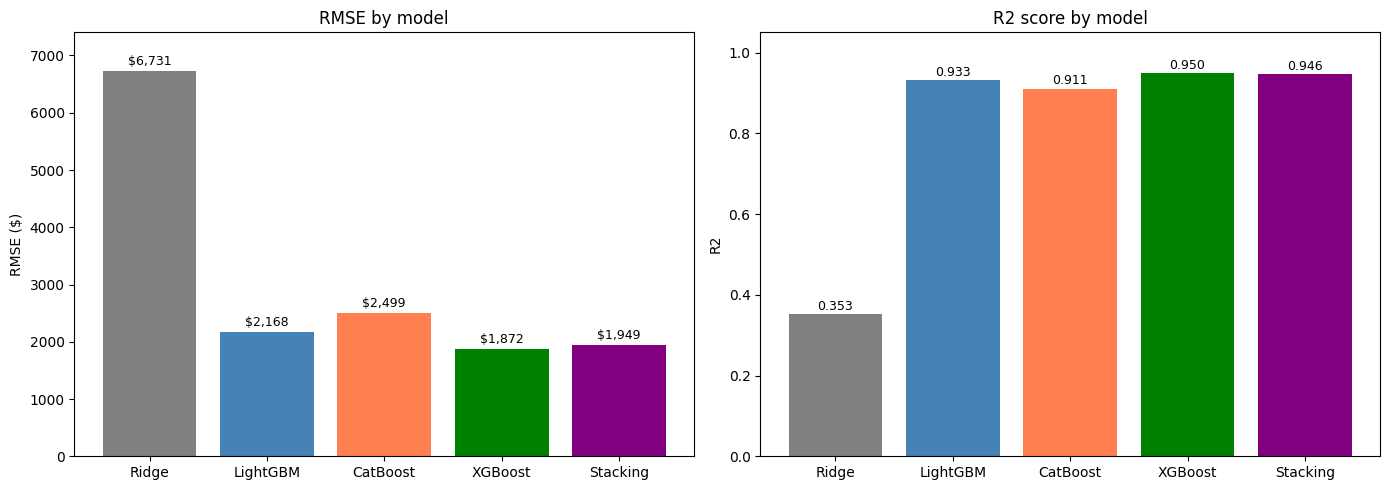

In [11]:
# compare all models visually
models = ['Ridge', 'LightGBM', 'CatBoost', 'XGBoost', 'Stacking']
rmses  = [baseline_rmse, lgb_rmse, cat_rmse, xgb_rmse, stack_rmse]
r2s    = [baseline_r2, lgb_r2, cat_r2, xgb_r2, stack_r2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# rmse chart
ax1.bar(models, rmses, color=['gray', 'steelblue', 'coral', 'green', 'purple'])
ax1.set_title('RMSE by model') #lower is better
ax1.set_ylabel('RMSE ($)')
ax1.set_ylim(0, max(rmses) * 1.1)
for i, v in enumerate(rmses):
    ax1.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

# r2 chart
ax2.bar(models, r2s, color=['gray', 'steelblue', 'coral', 'green', 'purple'])
ax2.set_title('R2 score by model') #higher is better
ax2.set_ylabel('R2')
ax2.set_ylim(0, 1.05)
for i, v in enumerate(r2s):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

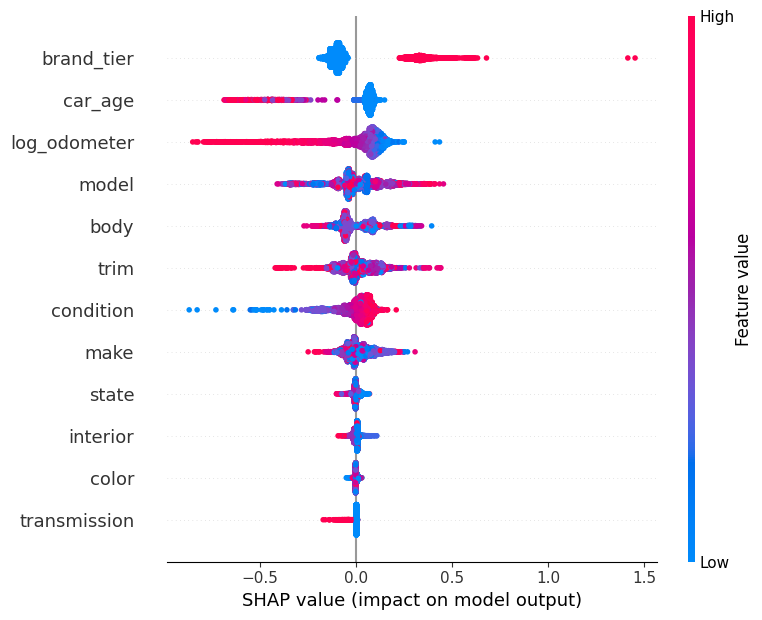

In [12]:
import shap

# shap on xgboost - best model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

# summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_val,
    feature_names=['car_age', 'log_odometer', 'condition', 'brand_tier',
                   'make', 'model', 'trim', 'body', 'transmission',
                   'state', 'color', 'interior'],
    show=True
)

In [13]:
import pickle

# save best model - xgboost
with open(base + 'models/xgb_best.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# save all val results
results = {
    'Ridge':    {'rmse': baseline_rmse, 'r2': baseline_r2},
    'LightGBM': {'rmse': lgb_rmse, 'r2': lgb_r2},
    'CatBoost': {'rmse': cat_rmse, 'r2': cat_r2},
    'XGBoost':  {'rmse': xgb_rmse, 'r2': xgb_r2},
    'Stacking': {'rmse': stack_rmse, 'r2': stack_r2},
}

with open(base + 'models/ml_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("saved xgb model and results")

saved xgb model and results
